# CVD screening model v4.1 — NHANES 2021–2023

This notebook builds the cardiovascular-disease (CVD) screening model from the public **NHANES
2021–2023** survey and evaluates it honestly. It replaces the earlier notebook, which used a small
pre-cleaned subset (536 train / 134 test rows) and tuned its decision threshold on the test set.

**Label.** `CVD = 1` when a doctor ever told the participant they had congestive heart failure,
coronary heart disease, angina, a heart attack or a stroke (NHANES `MCQ160B`–`MCQ160F`).
This is *existing, diagnosed* disease, measured at the same time as the inputs (cross-sectional).

**Evaluation rules used here**
1. A stratified 80 / 20 train–test split; the test set is used **once**, in section 7.
2. Model choice, calibration and decision thresholds come from 5-fold cross-validation on the
   training set only.
3. At 12.5 % prevalence accuracy and ROC AUC alone flatter the model, so we also report
   precision (PPV), NPV, PR-AUC and calibration.
4. Treatment inputs (BP and cholesterol medication) are left out of the model to avoid
   diagnosis proxies; section 8 measures what they would add.

The feature code lives in `Back-End/ml/nhanes.py` and is imported here, so the API computes
features with exactly the same code that trained the model.

## In one minute (what to say first)

* **Question:** given a patient's routine check-up data (age, blood pressure, cholesterol, kidney
  function, HbA1c, smoking, ...), how likely is it that they **already have** cardiovascular disease?
* **Data:** 5,330 US adults from the CDC's NHANES 2021–2023 survey, real measured lab values.
* **Model:** logistic regression with probability calibration. We tried 10 algorithms (XGBoost,
  LightGBM, neural network, SVM, random forest, stacking, ...). They all tied, so we kept the simplest
  and most explainable one.
* **Result on unseen test patients:** AUC **0.861** (95 % CI 0.829–0.890), sensitivity **90 %**,
  NPV **97.8 %**, calibration error **2 %**.
* **Main limitation (and why the app also uses PREVENT):** the label is disease that was *already
  diagnosed*. Diagnosed people are treated, so their cholesterol and blood pressure are *lower*.
  The model therefore cannot learn "high BP → high risk". We fixed this in two ways: guideline
  clinical alerts, and a second, prospective model (`cvd_mortality_v1.ipynb`).

### Structure of this notebook
1. Build the dataset → 2. Train/test split → 3. Compare 10 models → 4. Calibrate → 5. Choose
thresholds → 6. Train final model → 7. Test once → 8. Leakage check → 9. Why readings go the
"wrong" way → 10. Would more data help? → 11. Feature importance and saving the model.

### Glossary: how to read every metric in this notebook

| Metric | Plain meaning | Good value |
|---|---|---|
| **AUC (ROC AUC)** | Pick one sick and one healthy person at random: the chance the model gives the sick one the higher score. Measures *ranking*. | 0.5 = coin flip, 0.7 acceptable, 0.8 good, 0.9 excellent |
| **Sensitivity (recall)** | Of the people who really have the outcome, how many we flag. | High for screening (we chose ≥ 90 %) |
| **Specificity** | Of the people who do not have it, how many we correctly leave unflagged. | Trade-off with sensitivity |
| **PPV (precision)** | Of the people we flag, how many really have it. Depends heavily on how common the disease is. | Low when the disease is rare; that is normal |
| **NPV** | Of the people we call negative, how many really are negative. | Should be very high for a screening test |
| **PR-AUC** | Area under the precision–recall curve. Compare it with the prevalence (the "no skill" line). | Several times the prevalence |
| **Brier score** | Average squared error of the predicted probability. | Lower is better; 0 is perfect |
| **ECE (calibration error)** | Average gap between predicted risk and observed rate. "Says 10 %, happens 10 %?" | Close to 0 |
| **95 % CI** | Range the true AUC probably lies in, from 1,000 bootstrap resamples of the test set. | Narrow is better |
| **Cross-validation (5-fold)** | Split training data into 5 parts, train on 4, test on the 5th, rotate. Gives an honest estimate without touching the test set. | |

**Why not just accuracy?** Only 12.5 % (model A) or 3 % (model B) of people have the outcome. A model that
says "healthy" to everyone would score 87.5 % or 97 % accuracy and be useless. That is why we report
AUC, sensitivity, PPV, NPV and calibration instead.

In [1]:
import json, os, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
BACKEND = Path.cwd().parent if Path.cwd().name == "model" else Path.cwd()
sys.path.insert(0, str(BACKEND))
from ml._native import import_lightgbm
from ml.nhanes import (FEATURE_COLUMNS, FEATURE_LABELS, LABELS, MEDICATION_COLUMNS, RAW_CODED_COLUMNS,
                       RAW_COLUMNS, RAW_NUMERIC_COLUMNS, build_dataset, build_pipeline, model_coefficients)

lgb = import_lightgbm()
SEED = 42
TARGET_SENSITIVITY = 0.90   # screening use: miss at most ~10 % of people with CVD
ALERT_SPECIFICITY = 0.90    # "high" band: about 1 in 10 people without CVD reach it
MODEL_DIR = BACKEND / "model"
CACHE = Path(os.environ.get("NHANES_CACHE", MODEL_DIR / "nhanes_cache"))
np.random.seed(SEED)
print("sklearn", sklearn.__version__, "| lightgbm", lgb.__version__)

sklearn 1.6.1 | lightgbm 4.6.0


## 1. Build the dataset from NHANES

In [2]:
data = build_dataset(CACHE)  # downloads the .xpt tables from the CDC on first run, then reads the cache
data.to_csv(MODEL_DIR / "nhanes_cvd_2021_2023.csv", index=False)
X, y = data[RAW_COLUMNS], data["CVD"].to_numpy()
print(f"{len(data)} adults, {y.sum()} with CVD ({y.mean():.1%})")
age_groups = pd.cut(data.RIDAGEYR, [17, 30, 40, 50, 60, 70, 80])
display(pd.DataFrame({"patients": data.groupby(age_groups, observed=True).size(),
                      "CVD rate": data.groupby(age_groups, observed=True).CVD.mean().round(3)}))
display(X.isna().mean().sort_values(ascending=False).head(8).round(3).rename("missing share"))

5330 adults, 665 with CVD (12.5%)


,patients,CVD rate
RIDAGEYR,,
"(17, 30]",619,0.006
"(30, 40]",797,0.013
"(40, 50]",688,0.041
"(50, 60]",917,0.126
"(60, 70]",1307,0.174
"(70, 80]",1002,0.279


BPQ150      0.624
SMQ040      0.590
INDFMPIR    0.127
BMXWAIST    0.030
URDACT      0.013
LBXSCR      0.010
LBXSUA      0.010
SLD012      0.010
Name: missing share, dtype: float64

**What this shows.**
* 5,330 adults, of whom 665 (12.5 %) have diagnosed CVD.
* CVD climbs steeply with age, from 0.6 % in people up to 30 to 27.9 % at 70–80. Age will be the
  strongest input.
* Missing values: BP medication (62 %) and "smokes now" (59 %) are mostly missing because NHANES
  only asks them when they apply (skip pattern). For example, "smokes now?" is only asked to people
  who ever smoked. Everything else is almost complete.

**How the data is built (`ml/nhanes.py`).** Several NHANES tables are downloaded from the CDC and
joined on the participant ID (SEQN): demographics, blood pressure, body measures, labs and
questionnaires. Adults (18+) with measured blood pressure and cholesterol are kept. Then derived
features are calculated:
* **eGFR** (kidney function) from creatinine with the CKD-EPI 2021 equation;
* **non-HDL cholesterol** = total cholesterol − HDL, and the **cholesterol/HDL ratio**;
* **pulse pressure** = systolic − diastolic;
* **log transforms** for skewed labs (triglycerides, CRP, urine albumin/creatinine);
* one-hot race categories.

Missing values are filled with the training median, and a "was missing" flag is added. Inputs are
standardised. The **same code runs in the API**, so the app computes features exactly like
training did.

## 2. Train / test split

The test set (20 %) is put aside now and only used in sections 7 and 8.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
print(f"train {len(y_train)} ({y_train.sum()} CVD) | test {len(y_test)} ({y_test.sum()} CVD)")

train 4264 (532 CVD) | test 1066 (133 CVD)


**What this shows.** 4,264 people for training, 1,066 (20 %) locked away as the test set.
*Stratified* means both parts keep the same 12.5 % CVD rate. Everything from here to section 6 uses
the training part only. The test set is opened **once**, in section 7. This prevents "tuning on the
test set", which would make the results look better than they really are.

## 3. Model comparison (5-fold cross-validation on the training set)

Linear, tree-boosting, neural, kernel and stacked models, all on the same features, imputation and
scaling (`ml.nhanes.build_pipeline`). Class weights balance the 12.5 % prevalence during fitting;
section 4 calibrates the chosen model's output.

In [4]:
def lr(c=0.01):
    return LogisticRegression(C=c, max_iter=5000, class_weight="balanced")

def xgb():
    return XGBClassifier(n_estimators=600, learning_rate=0.01, max_depth=2, subsample=0.8, colsample_bytree=0.6,
                         min_child_weight=5, reg_lambda=5, scale_pos_weight=7, eval_metric="logloss",
                         n_jobs=-1, random_state=SEED, verbosity=0)

def lightgbm():
    return lgb.LGBMClassifier(n_estimators=600, learning_rate=0.01, num_leaves=4, min_child_samples=40,
                              subsample=0.8, subsample_freq=1, colsample_bytree=0.6, reg_lambda=5,
                              is_unbalance=True, verbosity=-1, random_state=SEED)

def hgb():
    return HistGradientBoostingClassifier(learning_rate=0.03, max_depth=3, max_iter=400, l2_regularization=1.0,
                                          class_weight="balanced", random_state=SEED)

def mlp():
    return MLPClassifier(hidden_layer_sizes=(32,), alpha=1.0, max_iter=2000, early_stopping=True, random_state=SEED)

# Listed from simplest to most complex (used by the selection rule).
candidates = {
    "Logistic regression (C=0.01)": lr(0.01),
    "Logistic regression (C=0.1)": lr(0.1),
    "Logistic regression (C=1)": lr(1),
    "Neural network (MLP)": mlp(),
    "SVM (RBF)": SVC(C=0.5, probability=True, class_weight="balanced", random_state=SEED),
    "Random forest": RandomForestClassifier(400, min_samples_leaf=5, class_weight="balanced", n_jobs=-1, random_state=SEED),
    "HistGradientBoosting": hgb(),
    "LightGBM": lightgbm(),
    "XGBoost": xgb(),
    "Stack (LR + XGBoost + HGB + MLP)": StackingClassifier(
        [("lr", lr()), ("xgb", xgb()), ("hgb", hgb()), ("mlp", mlp())], final_estimator=LogisticRegression(), cv=5, n_jobs=1),
}
rows, oof = [], {}
for name, model in candidates.items():
    fold_auc, pred = [], np.zeros(len(y_train))
    for tr, va in cv.split(X_train, y_train):
        fitted = build_pipeline(model).fit(X_train.iloc[tr], y_train[tr])
        pred[va] = fitted.predict_proba(X_train.iloc[va])[:, 1]
        fold_auc.append(roc_auc_score(y_train[va], pred[va]))
    oof[name] = pred
    rows.append({"model": name, "CV AUC (mean)": np.mean(fold_auc), "fold min": np.min(fold_auc),
                 "fold max": np.max(fold_auc), "CV PR-AUC": average_precision_score(y_train, pred)})
comparison = pd.DataFrame(rows).set_index("model").round(3)
display(comparison.sort_values("CV AUC (mean)", ascending=False))

,CV AUC (mean),fold min,fold max,CV PR-AUC
model,,,,
Stack (LR + XGBoost + HGB + MLP),0.875,0.840,0.897,0.480
LightGBM,0.873,0.835,0.899,0.482
XGBoost,0.873,0.837,0.897,0.484
Logistic regression (C=0.01),0.871,0.837,0.890,0.480
Logistic regression (C=0.1),0.868,0.833,0.888,0.477
Logistic regression (C=1),0.866,0.832,0.886,0.475
Random forest,0.865,0.828,0.889,0.460
HistGradientBoosting,0.860,0.824,0.884,0.458
SVM (RBF),0.854,0.827,0.873,0.438


**What this shows.**
* All ten models land between 0.844 and 0.875 CV AUC.
* The top four (stack, LightGBM, XGBoost and logistic regression) are within **0.004** of each
  other.
* The difference between folds (fold min to fold max, about 0.05) is **ten times bigger** than the
  gap between models. So no model is really better than another here.
* Complex models (neural net, SVM) are actually slightly worse: there is not enough signal in
  5,000 rows for extra complexity to help.

**Selection rule:** the simplest model whose CV AUC is within 0.005 of the best. The spread between
folds (about ±0.03) is several times larger than the gaps between the top models, so they are
statistically tied; the simplest one is then the better choice: it is explainable, calibrates
cleanly and its coefficients can be checked for clinical sense (section 9).

In [5]:
best = comparison["CV AUC (mean)"].max()
chosen = next(n for n in candidates if comparison.loc[n, "CV AUC (mean)"] >= best - 0.005)
print("best CV AUC", best, "-> chosen:", chosen)

best CV AUC 0.875 -> chosen: Logistic regression (C=0.01)


**Why logistic regression?** It ties with the best model (0.871 vs 0.875). It is also:
* **explainable:** each input has one coefficient a doctor can check;
* **stable:** it does not overfit on small data;
* **well calibrated** after Platt scaling;
* **fast and small** to serve on Vercel.

`C=0.01` means strong regularisation, which keeps the coefficients small and robust.

## 4. Probability calibration

Class weighting makes raw scores run far above the real CVD rate. A sigmoid (Platt) calibration
is fitted with internal 5-fold cross-validation (`CalibratedClassifierCV`), so the output becomes
an estimated probability of diagnosed CVD in this population. Ranking (AUC) is unchanged.
Compared here on out-of-fold training predictions.

,raw (class-weighted),calibrated
CV AUC,0.871,0.871
CV Brier (lower is better),0.146,0.082
mean score,0.338,0.125


actual CVD rate in training data: 0.125


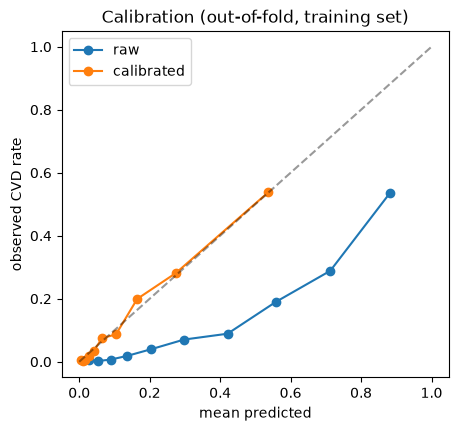

In [6]:
def calibrated():
    return CalibratedClassifierCV(candidates[chosen], method="sigmoid", cv=5)

oof_cal = cross_val_predict(build_pipeline(calibrated()), X_train, y_train, cv=cv, method="predict_proba")[:, 1]
display(pd.DataFrame({
    "raw (class-weighted)": [roc_auc_score(y_train, oof[chosen]), brier_score_loss(y_train, oof[chosen]), oof[chosen].mean()],
    "calibrated": [roc_auc_score(y_train, oof_cal), brier_score_loss(y_train, oof_cal), oof_cal.mean()],
}, index=["CV AUC", "CV Brier (lower is better)", "mean score"]).round(3))
print(f"actual CVD rate in training data: {y_train.mean():.3f}")
fig, ax = plt.subplots(figsize=(5, 4.5))
for label, scores in [("raw", oof[chosen]), ("calibrated", oof_cal)]:
    obs, pred = calibration_curve(y_train, scores, n_bins=10, strategy="quantile")
    ax.plot(pred, obs, "o-", label=label)
ax.plot([0, 1], [0, 1], "k--", alpha=.4); ax.set_xlabel("mean predicted"); ax.set_ylabel("observed CVD rate")
ax.set_title("Calibration (out-of-fold, training set)"); ax.legend(); plt.show()

**What this shows.**
* `class_weight="balanced"` helps the model learn the rare class, but it inflates the scores: the
  average raw score is 33.8 % while only 12.5 % really have CVD.
* After calibration the average score is **12.5 %**, exactly the real rate, and the Brier score
  drops from 0.146 to **0.082**. AUC is unchanged (0.871): calibration fixes the *scale* without
  changing the *ranking*.
* In the plot, the calibrated line lies on the diagonal. When the model says 20 %, about 20 % of
  those people really have CVD.

## 5. Decision thresholds (out-of-fold training predictions only)

* **Screening threshold:** the highest score that still catches ≥ 90 % of CVD cases.
  Below it the ML band is *low*.
* **Alert threshold:** the score exceeded by only 10 % of people without CVD (90 % specificity).
  At or above it the ML band is *high*; in between is *medium*.

In [7]:
pos_scores = np.sort(oof_cal[y_train == 1])
screen_threshold = float(pos_scores[int(np.floor((1 - TARGET_SENSITIVITY) * len(pos_scores)))])
alert_threshold = float(np.quantile(oof_cal[y_train == 0], ALERT_SPECIFICITY))

def operating_point(y_true, scores, t):
    flagged = scores >= t
    tn, fp, fn, tp = confusion_matrix(y_true, flagged, labels=[0, 1]).ravel()
    return {"threshold": t, "sensitivity": tp / (tp + fn), "specificity": tn / (tn + fp),
            "ppv": tp / (tp + fp), "npv": tn / (tn + fn), "flagged share": flagged.mean()}

display(pd.DataFrame({"screening": operating_point(y_train, oof_cal, screen_threshold),
                      "alert (high band)": operating_point(y_train, oof_cal, alert_threshold)}).round(3))

,screening,alert (high band)
threshold,0.078,0.253
sensitivity,0.900,0.581
specificity,0.659,0.900
ppv,0.274,0.452
npv,0.979,0.938
flagged share,0.411,0.160


**What this shows: how the Low / Medium / High bands are chosen.**
* **Low** is a score below **7.8 %**. This cut-off was chosen so that 90 % of real CVD cases score
  above it, so only 1 in 10 is missed. People below it are 97.9 % truly negative (NPV).
* **High** is a score of **25.3 %** or more. Only 10 % of healthy people reach it, and 45 % of
  people at this level really have CVD.
* **Medium** is everything in between.

The thresholds come from *out-of-fold training predictions*, never from the test set.

## 6. Fit the final calibrated model on the whole training set

In [8]:
final = build_pipeline(calibrated()).fit(X_train, y_train)

## 7. One-time evaluation on the held-out test set

In [9]:
prob = final.predict_proba(X_test)[:, 1]
screen = operating_point(y_test, prob, screen_threshold)
alert = operating_point(y_test, prob, alert_threshold)

rng = np.random.default_rng(SEED)
pos, neg = np.where(y_test == 1)[0], np.where(y_test == 0)[0]
boot = [roc_auc_score(y_test[i], prob[i]) for i in
        (np.concatenate([rng.choice(pos, len(pos)), rng.choice(neg, len(neg))]) for _ in range(1000))]
obs, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy="quantile")
bin_ids = np.digitize(prob, np.quantile(prob, np.linspace(0, 1, 11))[1:-1])
ece = float(sum(abs(prob[bin_ids == b].mean() - y_test[bin_ids == b].mean()) * (bin_ids == b).mean()
                for b in range(10) if (bin_ids == b).any()))
pred = prob >= screen_threshold
tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()

metrics = {
    "model_name": "CVD NHANES Logistic",
    "model_version": "4.1.0",
    "algorithm": f"{chosen}, sigmoid-calibrated (5-fold)",
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "data": "NHANES 2021-2023, adults 18+ with measured BP and cholesterol",
    "label": "Doctor-diagnosed CHF, CHD, angina, heart attack or stroke (MCQ160B-F)",
    "excluded_inputs": "BP and cholesterol medication (collected for AHA PREVENT only)",
    "n_train": int(len(y_train)), "n_test": int(len(y_test)), "prevalence": float(y.mean()),
    "threshold_rule": f"highest out-of-fold training score with sensitivity >= {TARGET_SENSITIVITY}",
    "decision_threshold": screen_threshold,
    "risk_bands": {"low_max": screen_threshold, "medium_max": alert_threshold},
    "auc": float(roc_auc_score(y_test, prob)),
    "auc_ci95": [float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))],
    "cv_auc": float(roc_auc_score(y_train, oof_cal)),
    "model_comparison_cv_auc": {k: float(v) for k, v in comparison["CV AUC (mean)"].items()},
    "pr_auc": float(average_precision_score(y_test, prob)),
    "sensitivity": float(screen["sensitivity"]), "recall": float(screen["sensitivity"]),
    "specificity": float(screen["specificity"]),
    "precision": float(screen["ppv"]), "ppv": float(screen["ppv"]), "npv": float(screen["npv"]),
    "balanced_accuracy": float((screen["sensitivity"] + screen["specificity"]) / 2),
    "accuracy": float((tp + tn) / len(y_test)),
    "f1": float(2 * tp / (2 * tp + fp + fn)),
    "flagged_share": float(screen["flagged share"]),
    "high_band": {k: float(alert[k]) for k in ["sensitivity", "specificity", "ppv", "npv"]},
    "brier": float(brier_score_loss(y_test, prob)),
    "ece": ece,
    "mean_predicted": float(prob.mean()), "observed_rate": float(y_test.mean()),
    "calibration": [{"mean_predicted": float(p), "observed_rate": float(o)} for p, o in zip(mean_pred, obs)],
    "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    "note": ("Cross-sectional label (existing diagnosed CVD): the score estimates the probability of "
             "already-diagnosed CVD in this population, not a 10-year risk. Use AHA PREVENT for that."),
}
display(pd.DataFrame({"screening threshold": screen, "high band": alert}).round(3))
display(pd.Series({k: metrics[k] for k in ["auc", "auc_ci95", "pr_auc", "brier", "ece", "mean_predicted", "observed_rate"]}))

,screening threshold,high band
threshold,0.078,0.253
sensitivity,0.902,0.624
specificity,0.633,0.870
ppv,0.260,0.407
npv,0.978,0.942
flagged share,0.433,0.191


auc                                               0.860616
auc_ci95          [0.8293619901844644, 0.8902191169241431]
pr_auc                                            0.489219
brier                                             0.083224
ece                                               0.020467
mean_predicted                                     0.13504
observed_rate                                     0.124765
dtype: object

**Final test results (the numbers to quote).**

| | Screening cut-off (7.8 %) | High band (25.3 %) |
|---|---|---|
| Sensitivity | **90.2 %** | 62.4 % |
| Specificity | 63.3 % | 87.0 % |
| PPV | 26.0 % | 40.7 % |
| NPV | **97.8 %** | 94.2 % |

* **AUC 0.861**, 95 % CI 0.829–0.890 (it was 0.871 in cross-validation, so there is no overfitting).
* **PR-AUC 0.489**, nearly **4×** the 12.5 % no-skill line.
* **Brier 0.083, ECE 0.020:** predicted risk is on average within 2 percentage points of reality.
  The mean prediction is 13.5 % against 12.5 % observed.
* The test results match the cross-validation results, which confirms the thresholds generalise.

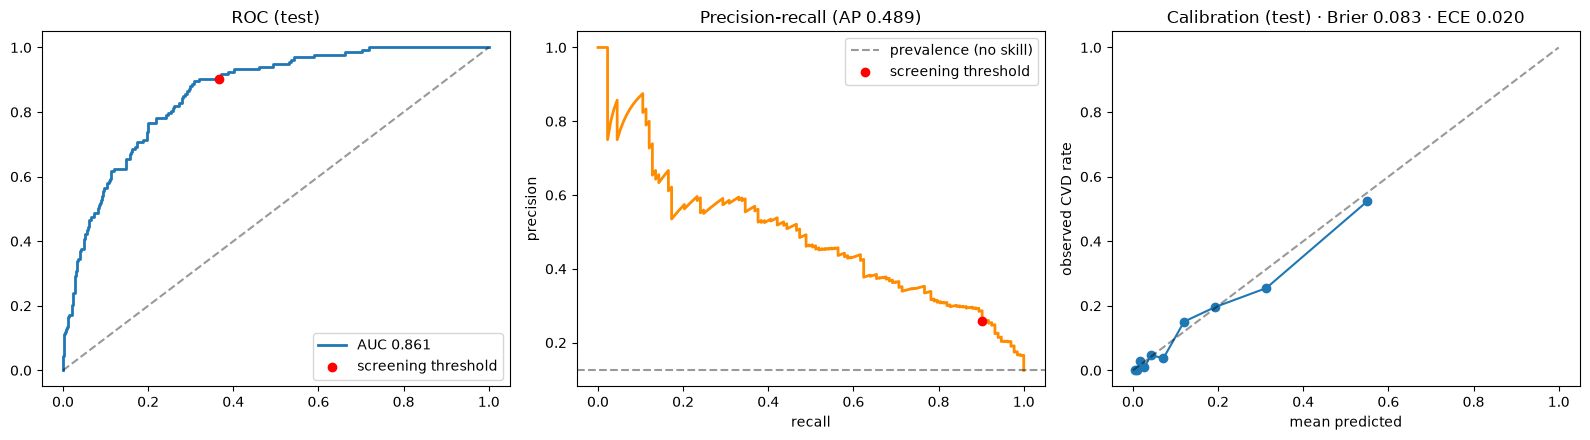

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
f, t, _ = roc_curve(y_test, prob)
ax[0].plot(f, t, lw=2, label=f"AUC {metrics['auc']:.3f}"); ax[0].plot([0, 1], [0, 1], "k--", alpha=.4)
ax[0].scatter([1 - screen["specificity"]], [screen["sensitivity"]], c="red", zorder=3, label="screening threshold")
ax[0].set_title("ROC (test)"); ax[0].legend()
p, r, _ = precision_recall_curve(y_test, prob)
ax[1].plot(r, p, lw=2, color="darkorange"); ax[1].axhline(y_test.mean(), ls="--", c="k", alpha=.4, label="prevalence (no skill)")
ax[1].scatter([screen["sensitivity"]], [screen["ppv"]], c="red", zorder=3, label="screening threshold")
ax[1].set_title(f"Precision-recall (AP {metrics['pr_auc']:.3f})"); ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision"); ax[1].legend()
ax[2].plot(mean_pred, obs, "o-"); ax[2].plot([0, 1], [0, 1], "k--", alpha=.4)
ax[2].set_title(f"Calibration (test) · Brier {metrics['brier']:.3f} · ECE {ece:.3f}")
ax[2].set_xlabel("mean predicted"); ax[2].set_ylabel("observed CVD rate")
plt.tight_layout(); plt.savefig(MODEL_DIR / "ml_full_train_diagnostic.png", dpi=150); plt.show()

**How to read the three plots.**
1. **ROC:** the further the curve bends to the top-left, the better. The red dot is our screening
   cut-off (90 % sensitivity).
2. **Precision–recall:** the dashed line is the no-skill level (12.5 %). The curve stays far above
   it.
3. **Calibration:** dots close to the diagonal mean the predicted percentages are honest.

**Reading the numbers.** At 12.5 % prevalence most flagged people do not have diagnosed CVD (PPV),
so a flag means "look closer", not "has CVD". A negative result is reliable (NPV). This is the
expected trade-off for a screening tool tuned for high sensitivity.

## 8. Data-leakage check

No post-event variables (hospital stay, procedures) are used. The closest are treatment and
diagnosis-history answers, which can reflect an existing diagnosis. Each variant below is trained
on the training set and scored on the test set (diagnostic only; the served model is not changed).

In [11]:
history = ["high_bp_hx", "high_chol_hx", "diabetes"]
variants = {
    "served model (no medication inputs)": FEATURE_COLUMNS,
    "+ BP and cholesterol medication": FEATURE_COLUMNS + MEDICATION_COLUMNS,
    "- diagnosis history (high BP, high cholesterol, diabetes)": [c for c in FEATURE_COLUMNS if c not in history],
    "- diagnosis history - self-rated health": [c for c in FEATURE_COLUMNS if c not in history + ["gen_health"]],
}
leak = {}
for name, cols in variants.items():
    q = build_pipeline(calibrated(), columns=cols).fit(X_train, y_train).predict_proba(X_test)[:, 1]
    leak[name] = {"test AUC": roc_auc_score(y_test, q), "test PR-AUC": average_precision_score(y_test, q)}
display(pd.DataFrame(leak).T.round(3))
metrics["leakage_check"] = {k: {kk: float(vv) for kk, vv in v.items()} for k, v in leak.items()}

,test AUC,test PR-AUC
served model (no medication inputs),0.861,0.489
+ BP and cholesterol medication,0.863,0.482
"- diagnosis history (high BP, high cholesterol, diabetes)",0.853,0.469
- diagnosis history - self-rated health,0.825,0.417


**What this shows.**
* **Medication** (BP and cholesterol tablets) could be a "proxy" for the diagnosis: people take
  them *because* they were diagnosed. Adding them changes the AUC by only +0.002. So the model is
  not cheating with them, and we exclude them to be safe.
* **Removing diagnosis history** (high BP, high cholesterol, diabetes) costs only 0.008. Removing
  self-rated health as well costs 0.036. These are facts known at the visit, not information from
  the future, so they are legitimate inputs.

Medication inputs add almost nothing, so they are not what drives performance and are excluded.
Diagnosis history and self-rated health carry real signal; they are facts known at the visit
(not post-event data), so they stay.

## 9. Why the model cannot learn "higher readings → higher risk"

The label is *already-diagnosed* CVD. Once diagnosed, patients are treated: statins lower their
cholesterol and BP medicines lower their blood pressure. A cross-sectional model therefore sees
people **with** CVD carrying **lower** measured cholesterol.

In [12]:
coef = model_coefficients(final).sort_values(key=abs, ascending=False)
display(coef.head(15).round(3).rename("standardised coefficient (mean of calibration folds)"))
treated = data.assign(statin=data.BPQ101D.eq(1))
display(treated.groupby(["CVD", "statin"]).LBXTC.agg(["count", "mean"]).round(1)
        .rename(columns={"count": "patients", "mean": "mean total cholesterol"}))

age              0.630
gen_health       0.487
high_bp_hx       0.328
high_chol_hx     0.308
smoker_ever      0.241
egfr            -0.210
total_chol      -0.194
non_hdl         -0.152
male             0.142
hdl             -0.133
sleep_weekday    0.120
log_uacr         0.111
race_mexican    -0.106
education       -0.103
rdw              0.100
Name: standardised coefficient (mean of calibration folds), dtype: float64

patients  mean total cholesterol
CVD statin                                  
0   False       3585                   196.0
    True        1080                   176.4
1   False        208                   184.4
    True         457                   159.3

**How to read the coefficients.** Inputs are standardised, so each coefficient is the change in
log-odds for a one-standard-deviation increase. Positive means higher risk.
* **Age (+0.63)** is by far the strongest, then **poor self-rated health**, **history of high BP**
  and **high cholesterol**, and **ever smoked**.
* **Total cholesterol is negative (−0.19).** The second table shows why. People with CVD who take
  statins average **159 mg/dL**, against **196 mg/dL** for untreated people without CVD. The
  treatment lowered the number that "caused" the disease. This is **reverse causation**.

In [13]:
base = X_train.median(numeric_only=True)
probe = pd.DataFrame([base] * 4)
for c in RAW_CODED_COLUMNS: probe[c] = X_train[c].mode().iloc[0]
probe["RIDAGEYR"] = [21, 21, 65, 65]
probe["BPXOSY1"], probe["BPXODI1"], probe["LBXTC"] = [190, 118, 190, 118], [110, 75, 110, 75], [300, 170, 300, 170]
probe["probability"] = final.predict_proba(probe[RAW_COLUMNS])[:, 1].round(3)
display(probe[["RIDAGEYR", "BPXOSY1", "BPXODI1", "LBXTC", "probability"]])

,RIDAGEYR,BPXOSY1,BPXODI1,LBXTC,probability
0,21,190,110,300,0.003
1,21,118,75,170,0.010
2,65,190,110,300,0.016
3,65,118,75,170,0.058


**The proof.** A 21-year-old with BP 190/110 and cholesterol 300 scores **0.3 %**, *lower* than
the same person with normal readings (1.0 %). A cross-sectional model cannot be used alone to
judge a single patient's future risk.

**This is the key point for the discussion.** It is the reason the app adds the AHA PREVENT
equations, clinical alerts and the prospective death model.

High BP and cholesterol do **not** raise this score. This is why the app pairs the model with
(a) guideline clinical alerts and (b) the AHA PREVENT equations, which come from long-term
follow-up studies and correctly raise 10-year risk with higher BP and cholesterol.

## 10. Would more data help? (learning curve, cross-validated)

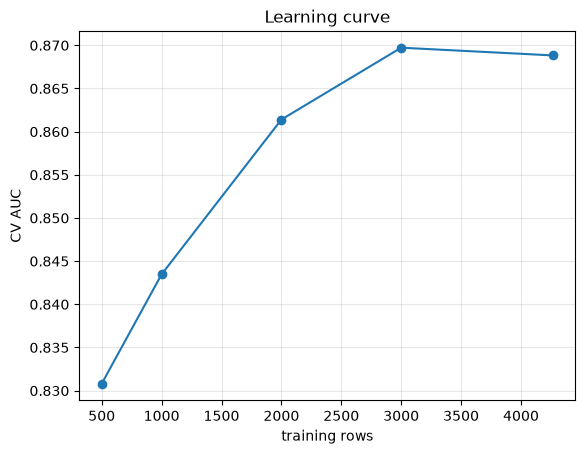

{500: np.float64(0.831), 1000: np.float64(0.843), 2000: np.float64(0.861), 3000: np.float64(0.87), 4264: np.float64(0.869)}


In [14]:
sizes, curve = [500, 1000, 2000, 3000, len(y_train)], []
for n in sizes:
    aucs = []
    for seed in range(5):
        idx = np.random.default_rng(seed).choice(len(y_train), n, replace=False) if n < len(y_train) else np.arange(n)
        p = cross_val_predict(build_pipeline(candidates[chosen]), X_train.iloc[idx], y_train[idx],
                              cv=StratifiedKFold(5, shuffle=True, random_state=seed), method="predict_proba")[:, 1]
        aucs.append(roc_auc_score(y_train[idx], p))
    curve.append(np.mean(aucs))
plt.plot(sizes, curve, "o-"); plt.xlabel("training rows"); plt.ylabel("CV AUC"); plt.title("Learning curve"); plt.grid(alpha=.3); plt.show()
print(dict(zip(sizes, np.round(curve, 3))))

**What this shows.** AUC goes 0.831 → 0.843 → 0.861 → 0.870 → 0.869 as the training rows grow.
It flattens after about 3,000 rows. More rows of the same kind would not reach 0.90. The limit comes
from **what the label measures**, not from the amount of data or the algorithm. This is why the
next step was a different, prospective dataset rather than a bigger model.

The curve flattens: more rows of the same survey add little. The ceiling comes from the label and
the cross-sectional design, not from the algorithm.

## 11. Feature importance and exported artifacts

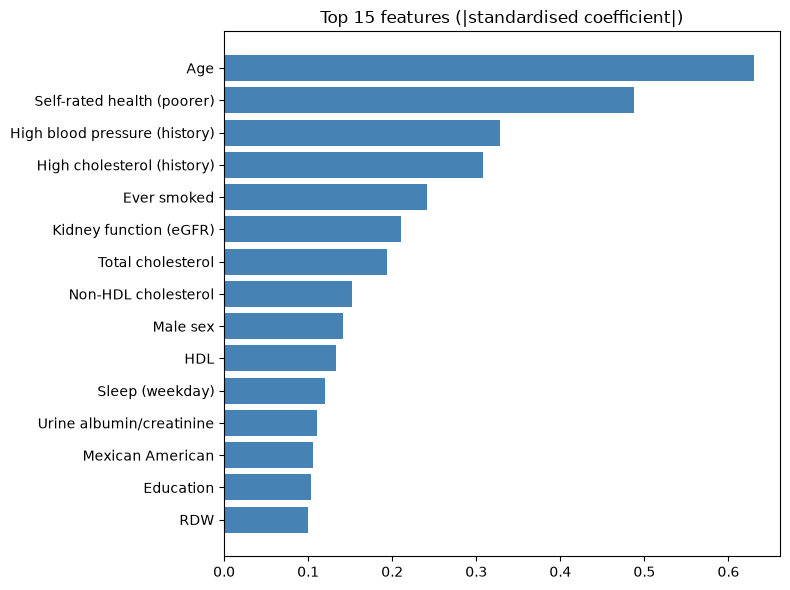

saved: cvd_pipeline.joblib, feature_importance.png, feature_schema.json, metrics_ml.json, ml_full_train_diagnostic.png, nhanes_cvd_2021_2023.csv


In [15]:
top = coef.abs().sort_values().tail(15)
plt.figure(figsize=(8, 6)); plt.barh([FEATURE_LABELS.get(n, n) for n in top.index], top.values, color="steelblue")
plt.title("Top 15 features (|standardised coefficient|)"); plt.tight_layout()
plt.savefig(MODEL_DIR / "feature_importance.png", dpi=150); plt.show()

reference = {c: float(X_train[c].median()) for c in RAW_NUMERIC_COLUMNS}
reference.update({c: float(X_train[c].mode().iloc[0]) for c in RAW_CODED_COLUMNS})
schema = {
    "model_name": metrics["model_name"], "model_version": metrics["model_version"],
    "raw_columns": RAW_COLUMNS, "numeric_columns": RAW_NUMERIC_COLUMNS, "coded_columns": RAW_CODED_COLUMNS,
    "reference_values": {k: round(v, 4) for k, v in reference.items()},
    "labels": {c: LABELS[c] for c in RAW_COLUMNS}, "decision_threshold": screen_threshold,
}
joblib.dump(final, MODEL_DIR / "cvd_pipeline.joblib", compress=3)
(MODEL_DIR / "feature_schema.json").write_text(json.dumps(schema, indent=2) + "\n")
(MODEL_DIR / "metrics_ml.json").write_text(json.dumps(metrics, indent=2) + "\n")
print("saved:", ", ".join(p.name for p in sorted(MODEL_DIR.glob("*")) if p.suffix in {".joblib", ".json", ".png", ".csv"}))

**What gets saved and used by the app.**
* `cvd_pipeline.joblib`: the full pipeline (feature code → imputation → scaling → calibrated
  logistic regression). The API loads it and calls `predict_proba`.
* `feature_schema.json`: the input columns and median "reference" values used for missing inputs
  and for explaining each prediction.
* `metrics_ml.json`: every metric above plus the risk bands. The app's Models page reads these
  numbers.
* `feature_importance.png` and `ml_full_train_diagnostic.png`: the charts above.

## Summary and likely questions

**Summary.** On 5,330 NHANES adults, a calibrated logistic regression detects existing CVD with
AUC 0.861, 90 % sensitivity and 97.8 % NPV. Its probabilities are well calibrated (ECE 0.02).
Because the label is existing disease, measured readings run in the "wrong" direction, so the app
combines it with AHA PREVENT, clinical alerts and a prospective model.

**Q: Why not deep learning / XGBoost?** We tested them (section 3). They tie within 0.004 AUC, which
is far less than the 0.05 noise between folds. Logistic regression is just as accurate, explainable
and calibrated.

**Q: Your old notebook said 83.6 % accuracy. Why is this better?** The old one used 670 pre-cleaned
rows and chose its threshold on the test set, which makes results look better than they are. This
one uses 8× more real patients, a test set used once, and reports AUC, PPV, NPV and calibration.
Accuracy alone is misleading at 12.5 % prevalence.

**Q: Why is PPV only 26 %?** Because CVD is uncommon (12.5 %). With 90 % sensitivity, some healthy
people must be flagged. For a screening tool that is the right trade-off: a flag means "look closer",
and a negative result is 97.8 % reliable.

**Q: Is there data leakage?** Section 8: medications add +0.002 AUC and are excluded. No
post-diagnosis data (hospital stays, procedures) is used. The test set was used once.

**Q: Why can't it reach 90 % AUC?** Section 10: the learning curve is flat. The ceiling is the
label (existing diagnosis), not the algorithm. The prospective model reaches 0.909.

**Q: Why does high BP give a low score?** Section 9: reverse causation. Diagnosed patients are
treated, so their readings are lower. That is why PREVENT and the clinical alerts are part of the
final risk level.